# **Kaggle Tabular Project**
Mushroom Classification

---



# Project Objective

link to dataset:  https://www.kaggle.com/datasets/uciml/mushroom-classification

challenge description:  Predict if the mushroom is edible or poisonous, using the datset given from the UCI Machine Learning Repository that was drawn from *The Audubon Society Field Guide to North American Mushrooms* (1981). The mushrooms samples are derived from the Agaricus and Lepitoe mushroom family, and each mushroom is identified as either edible (e) or poisonous(p).

Data description:  The dataset has 8,124 mushroom samples with 23 column of classes and physical features. Different letters correspond to physical charateristics.

#**Initial Look and Data Loading**

In [ ]:
import pandas as pd

df = pd.read_csv("mushrooms.csv")

print("Data Shape:")
print("Rows, Columns:", df.shape)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nData Head:")
df.head()

Data Shape:
Rows, Columns: (8124, 23)

Missing values per column:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Data Head:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
summary = []

for col in df.columns:
    unique_vals = df[col].unique()
    summary.append({
        "Feature": col,
        "Type": "Categorical",
        "Unique Values": unique_vals[:5],
        "Num Unique": len(unique_vals),
        "Missing": df[col].isnull().sum()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Feature,Type,Unique Values,Num Unique,Missing
0,class,Categorical,"[p, e]",2,0
1,cap-shape,Categorical,"[x, b, s, f, k]",6,0
2,cap-surface,Categorical,"[s, y, f, g]",4,0
3,cap-color,Categorical,"[n, y, w, g, e]",10,0
4,bruises,Categorical,"[t, f]",2,0
5,odor,Categorical,"[p, a, l, n, f]",9,0
6,gill-attachment,Categorical,"[f, a]",2,0
7,gill-spacing,Categorical,"[c, w]",2,0
8,gill-size,Categorical,"[n, b]",2,0
9,gill-color,Categorical,"[k, n, g, p, w]",12,0


###Missing values and Outliers



*   There are no missing values in the dataset.
*   Definetion of outliers: Data points that are significanlty different from the rest of the data, often skweing the statistical results.
* From the dataset given there are no outliers as this is a categorical dataset.


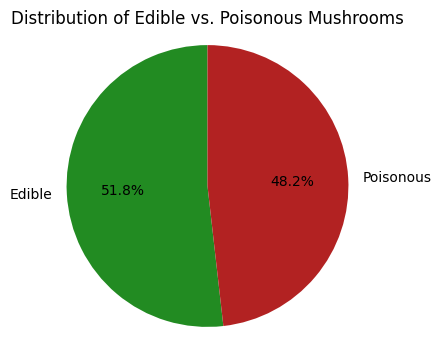

In [ ]:
import matplotlib.pyplot as plt

class_counts = df['class'].value_counts()
labels = ['Edible' if c == 'e' else 'Poisonous' for c in class_counts.index]
colors = ['forestgreen', 'firebrick']

plt.figure(figsize=(4, 4))
plt.pie(class_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Edible vs. Poisonous Mushrooms')
plt.axis('equal')
plt.show()

###Classification Imbalance

From the pie chart it is evident that there is no class inbalance as there is an almost 50/50 slipt between the two classes

#**Data Visualization**

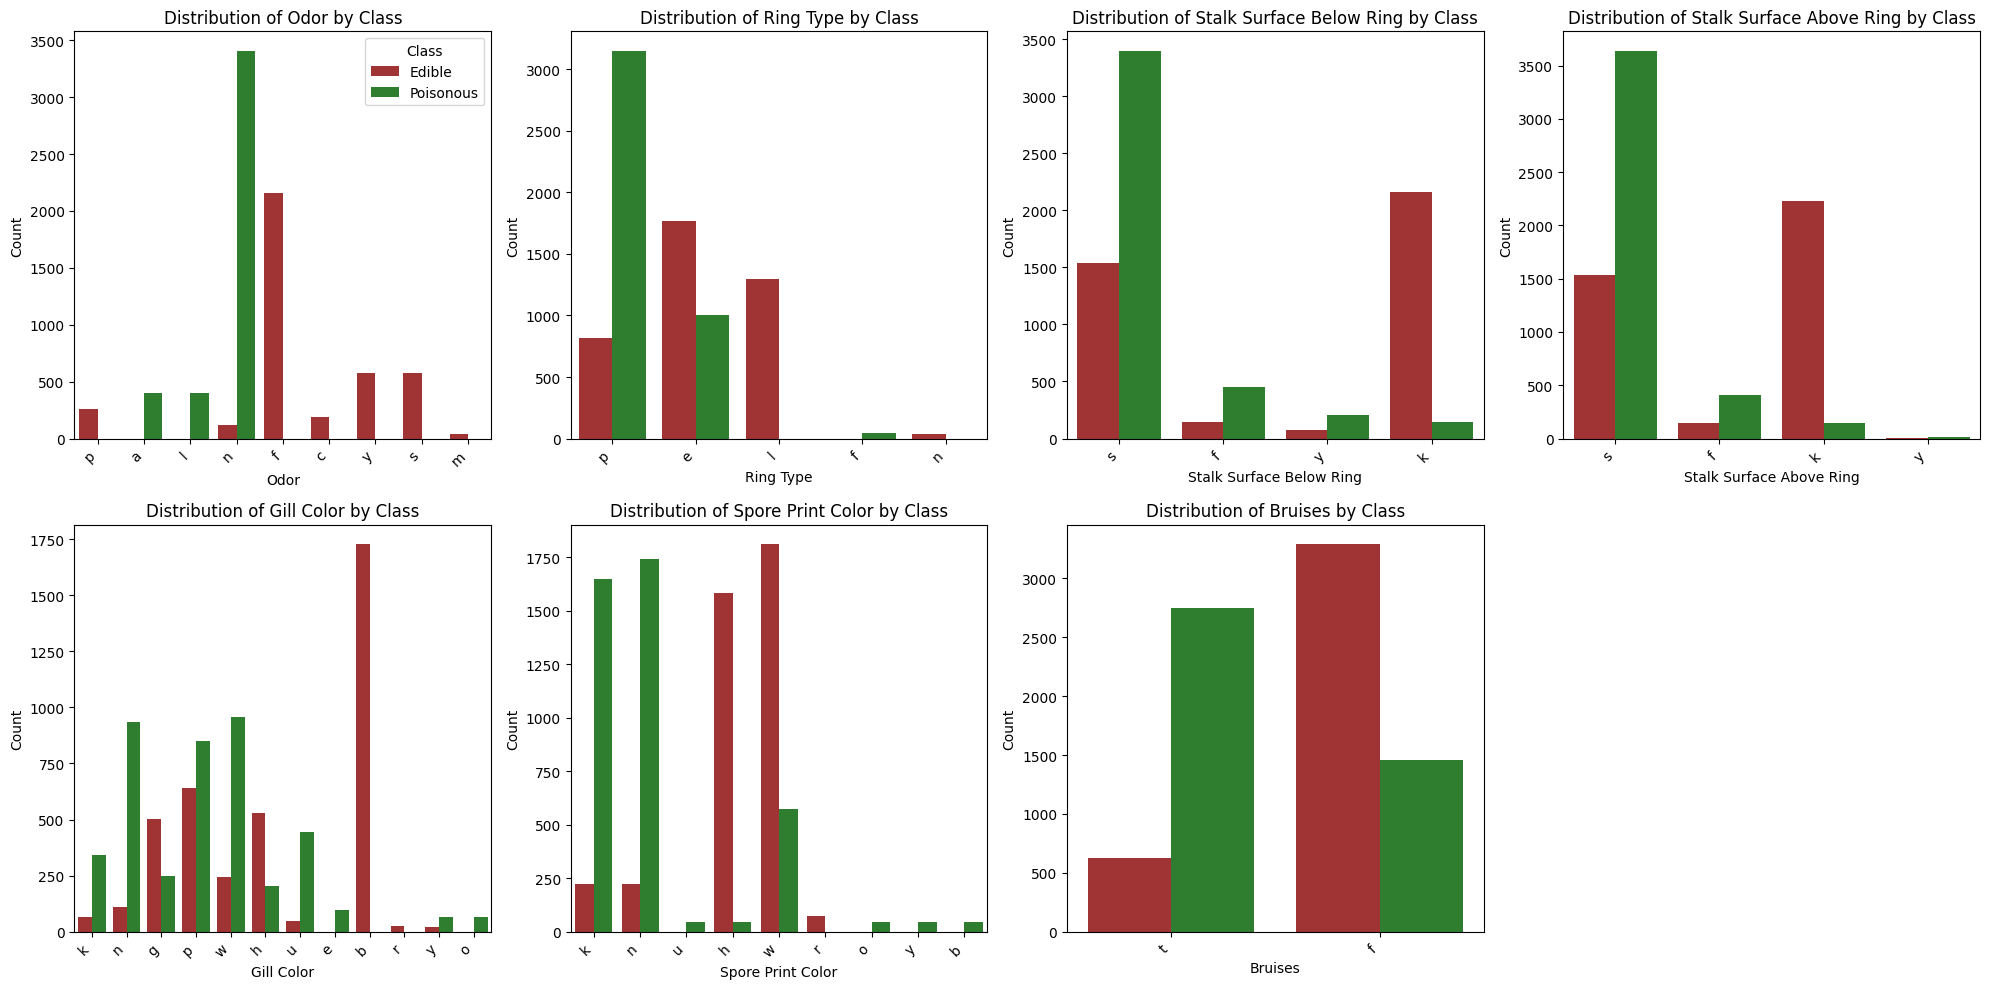

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

promising_features = [
    'odor',
    'ring-type',
    'stalk-surface-below-ring',
    'stalk-surface-above-ring',
    'gill-color',
    'spore-print-color',
    'bruises'
]

num_features = len(promising_features)
num_cols = 4
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 5))

for i, feature in enumerate(promising_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(data=df, x=feature, hue='class', palette={'e': 'forestgreen', 'p': 'firebrick'})
    plt.title(f'Distribution of {feature.replace("-", " ").title()} by Class')
    plt.xlabel(feature.replace("-", " ").title())
    plt.ylabel('Count')

    if i == 0:
        plt.legend(title='Class', labels=['Edible', 'Poisonous'])
    else:
        plt.legend([],[], frameon=False)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


###**Promising Features for Classification**



*   Odor: Clear disctinction between poisonous and edible as almost 100% of the mushrooms are clearly divided into their respective classes. Making it a very good indicator of poisonous or edible.
*   Ring-type:decent indicator, but does not show a clear dictinction like odor.
* Stalk Surface above ring: Shows a distinction between the two classes but not greatly so.
* Gill color: Decent indicator as some colors are more associated with a class.
* Spore print color: Like odor, this feature shows a clear discintion between poisonous and edible.
* Bruises: While not as good as other indicators, it does show a some dictinction between the two classes.




###**Data Cleaning and Prep**

In [ ]:
df_processed = df.drop(columns=['veil-type']).copy()

Dropping veil type as it is only has one value in it, and thus hold no predictive power.

In [ ]:
# e=edible, p=poisonous to 0, 1
df_processed['class'] = df_processed['class'].map({'e': 0, 'p': 1})
print("Encoded 'class' column:")
print(df_processed['class'].value_counts())


Encoded 'class' column:
class
0    4208
1    3916
Name: count, dtype: int64


In [ ]:
#one-hot encode
X = df_processed.drop(columns=['class'])
y = df_processed['class']

X_encoded = pd.get_dummies(X, drop_first=True)

recaling not needed as all features become binary after encoding

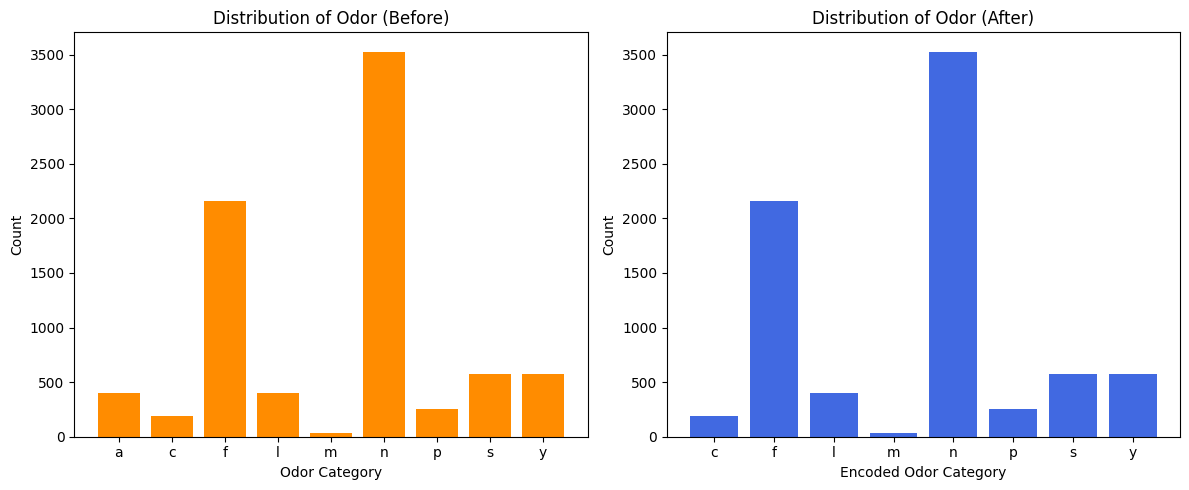

In [ ]:
# Before One-Hot Encode
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cap_shape_counts_before = df['odor'].value_counts().sort_index()
plt.bar(cap_shape_counts_before.index, cap_shape_counts_before.values, color='darkorange')
plt.title('Distribution of Odor (Before)')
plt.xlabel('Odor Category')
plt.ylabel('Count')
plt.xticks(rotation=0)

# After One-Hot encode
odor_cols = [col for col in X_encoded.columns if col.startswith('odor_')]
odor_encoded_counts = X_encoded[odor_cols].sum()

plt.subplot(1, 2, 2)
category_labels = [col.split('_')[-1] for col in odor_encoded_counts.index]
plt.bar(category_labels, odor_encoded_counts.values, color='royalblue')
plt.title('Distribution of Odor (After)')
plt.xlabel('Encoded Odor Category')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

###**Machine Learning**

In [ ]:
from sklearn.model_selection import train_test_split

# training (60%), validation (20%), and test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, test_size=0.4, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Val shape: {X_val.shape}, {y_val.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")

Train shape: (4874, 95), (4874,)
Val shape: (1625, 95), (1625,)
Test shape: (1625, 95), (1625,)


### Training and Visualizing a Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)

print("Decision Tree Classifier trained")

Decision Tree Classifier trained


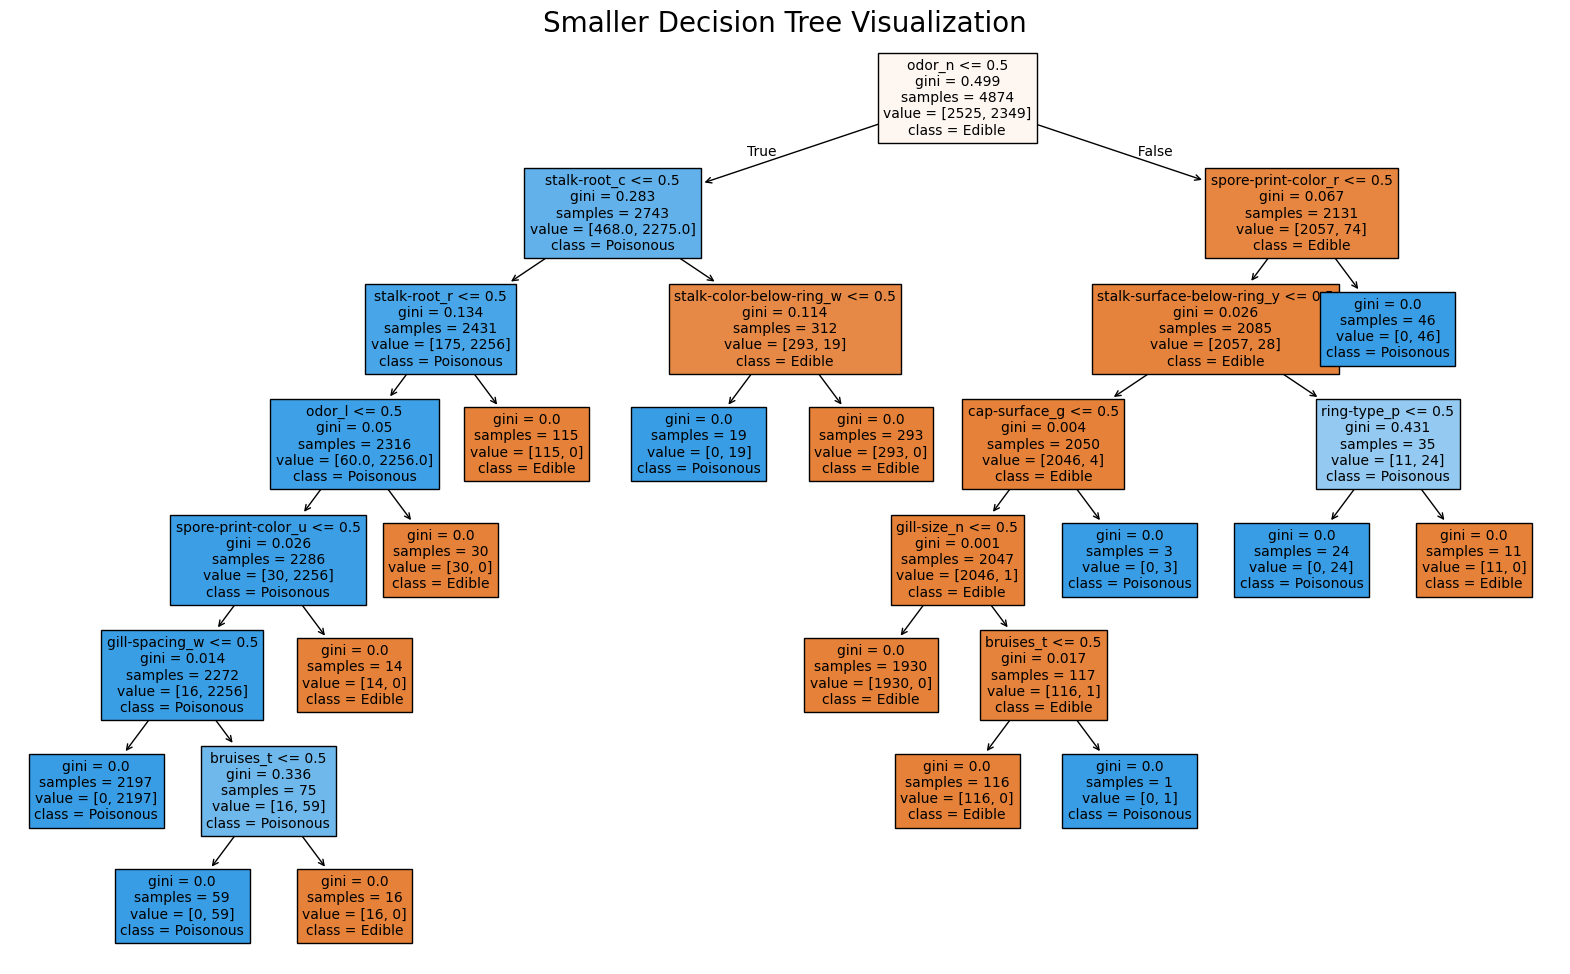

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
plot_tree(dtc_model, filled=True, feature_names=X_encoded.columns.tolist(), class_names=['Edible', 'Poisonous'], fontsize=10,)
plt.title('Smaller Decision Tree Visualization', fontsize=20)
plt.show()

Decision Tree Test Accuracy: 1.0000

Decision Tree Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


Decision Tree Test Confusion Matrix:
[[842   0]
 [  0 783]]


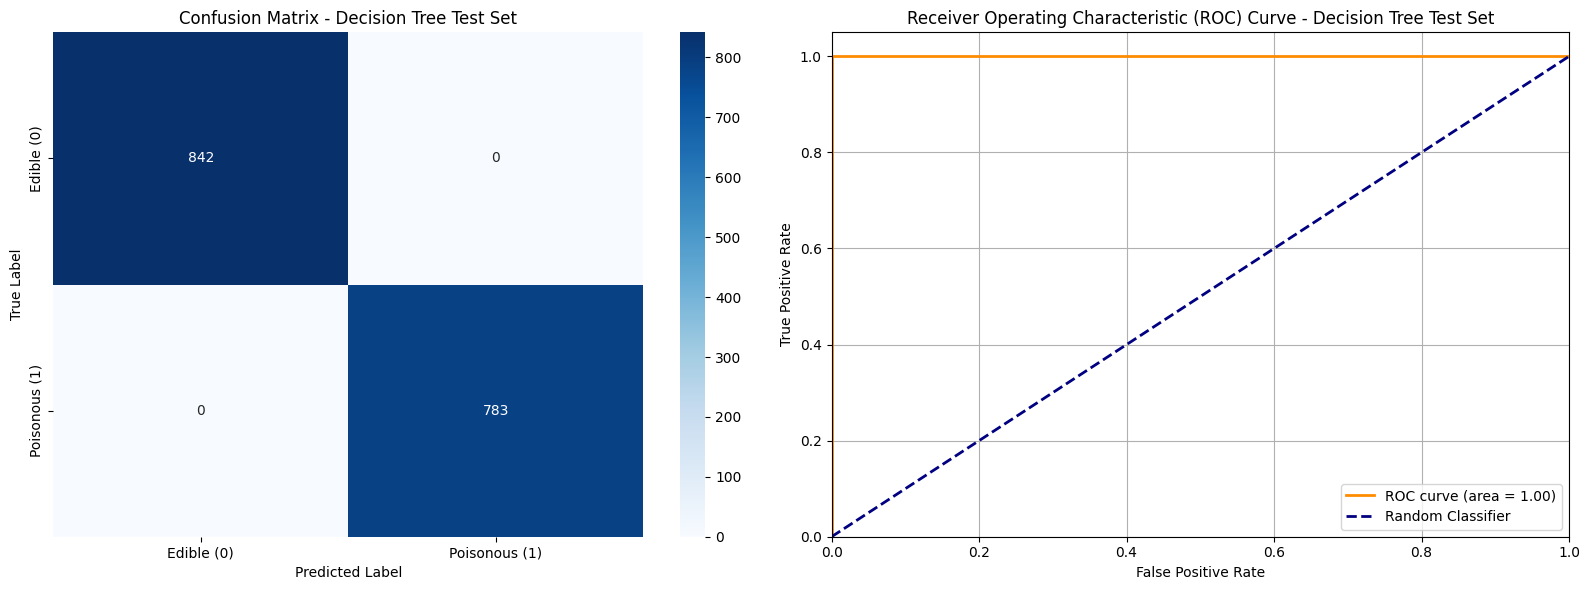

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

y_pred_dtc = dtc_model.predict(X_test)


accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
report_dtc = classification_report(y_test, y_pred_dtc)
conf_matrix_dtc = confusion_matrix(y_test, y_pred_dtc)

print(f"Decision Tree Test Accuracy: {accuracy_dtc:.4f}")
print("\nDecision Tree Test Classification Report:")
print(report_dtc)
print("\nDecision Tree Test Confusion Matrix:")
print(conf_matrix_dtc)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(conf_matrix_dtc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible (0)', 'Poisonous (1)'],
            yticklabels=['Edible (0)', 'Poisonous (1)'], ax=axes[0])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix - Decision Tree Test Set')


y_pred_proba_dtc = dtc_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_dtc)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve - Decision Tree Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

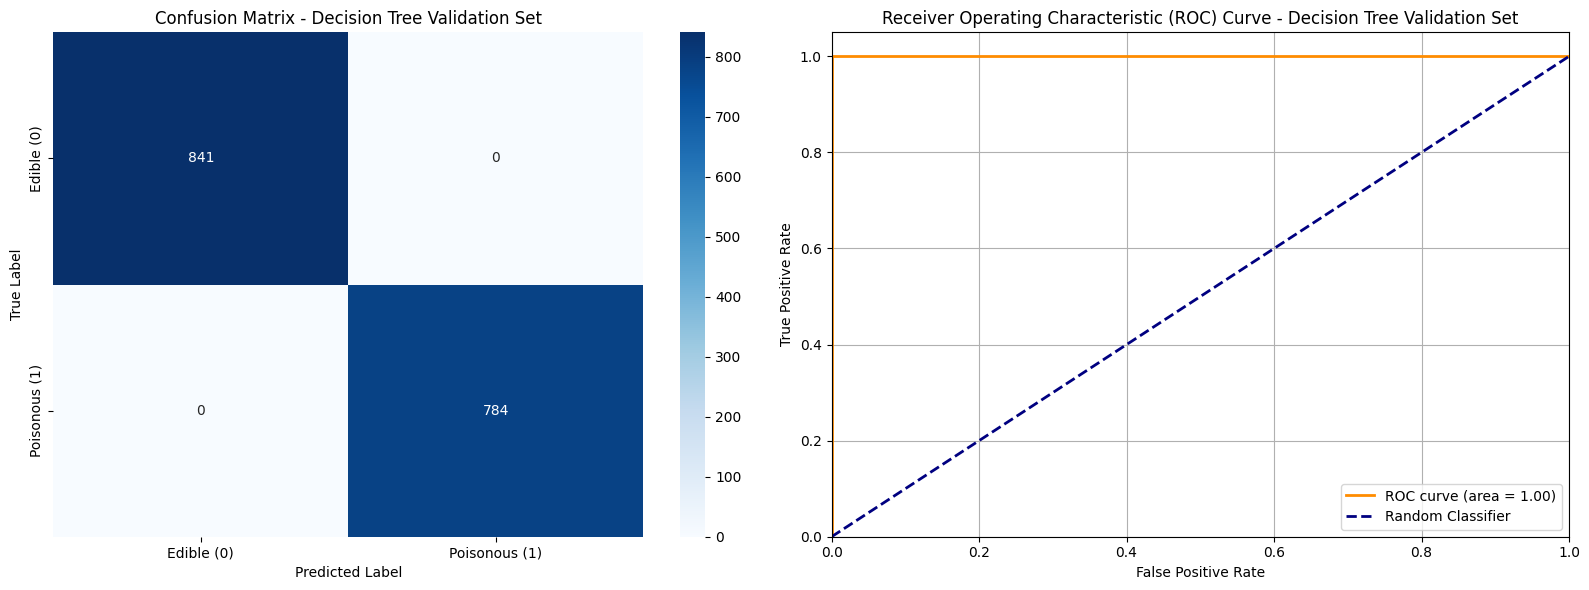

In [ ]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred_val_dtc = dt_classifier.predict(X_val)

conf_matrix_val_dtc = confusion_matrix(y_val, y_pred_val_dtc)

y_pred_proba_val_dtc = dt_classifier.predict_proba(X_val)[:, 1]
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_pred_proba_val_dtc)
roc_auc_val = auc(fpr_val, tpr_val)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(conf_matrix_val_dtc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible (0)', 'Poisonous (1)'],
            yticklabels=['Edible (0)', 'Poisonous (1)'], ax=axes[0])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix - Decision Tree Validation Set')

axes[1].plot(fpr_val, tpr_val, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve - Decision Tree Validation Set')
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Confusion Matrix**: The confusion matricies confirm that the decision tree on the test and validation set had perfect performance, classyfing everything perfectly with no false positives or negatives.

**ROC Curve**: The ROC Curve evaluates the performance of the decision tree. Both ROC curves show that the decision tree was able to correctly classify everything into their repective class, further confirming the confusion matricies.

In [ ]:
submission_df = pd.DataFrame({
    'ID': X_test.index,
    'Predicted_Class': y_pred_dtc
})

submission_df['Predicted_Class'] = submission_df['Predicted_Class'].map({0: 'e', 1: 'p'})

submission_df.to_csv('submission.csv', index=False)

print("Submission file created successfully.")
print(submission_df.head())

Submission file created successfully.


,ID,Predicted_Class
0,2228,e
1,6648,p
2,5917,e
3,6761,p
4,3100,e
